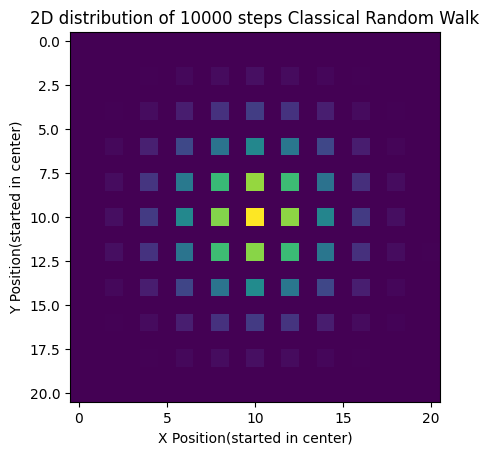

In [ ]:
import math
from numpy import *
import numpy as np
import random
from matplotlib import pyplot as plt

def classicalRanNum():
    coinX = int(random.choice(['1', '-1']))
    coinY = int(random.choice(['1', '-1']))
    return coinX, coinY

def classicalWalkerPosition():
    positionX = 0
    positionY = 0
    return positionX, positionY

def classicalWalk(walkNum):
    walkerPositionX, walkerPositionY = classicalWalkerPosition()
    for i in range(0, walkNum):
        coinX, coinY = classicalRanNum()
        walkerPositionX += coinX
        walkerPositionY += coinY
    return walkerPositionX, walkerPositionY

def classicalRWDistr(walkNum, matrixNum,satNum):
    walkerCount = zeros([2 *matrixNum + 1, 2 * matrixNum + 1])
    for i in range(0, satNum):
        walker = classicalWalk(walkNum)
        walkerCount[walker[0]+matrixNum][walker[1]+matrixNum] += float(1.0 / satNum)
    return walkerCount

def Plot2D(classcialWalker,steps):
    plt.figure(1)
    ax1=plt.subplot(111)
    plt.sca(ax1)
    plt.title('2D distribution of %s steps Classical Random Walk' %steps)
    plt.xlabel('X Position(started in center)')
    plt.ylabel('Y Position(started in center)')
    plt.imshow(classcialWalker)
    plt.show()

for i in range(1,2):
    classicalWalker=classicalRWDistr(i*10,10,100000)
    Plot2D(classicalWalker,i*10000)

This plot shows that a 2D simple random walk is normally distributed.

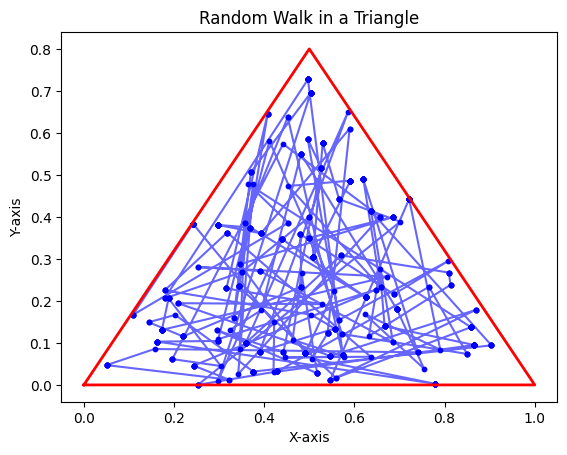

In [ ]:
import random
import matplotlib.pyplot as plt
from math import sqrt

def getRandom(size, stddev, avg):
    samples = [random.random() - 0.5 for _ in range(size)]
    R = sum(samples) * (sqrt(size / 12))
    R *= stddev
    R += avg
    return R

def random_walk_triangle(start_x, start_y, steps, stddev, avg):
    x, y = [start_x], [start_y]

    for _ in range(steps):
        dx = getRandom(10, stddev, avg)
        dy = getRandom(10, stddev, avg)
        new_x, new_y = x[-1] + dx, y[-1] + dy
        if 0 <= new_x <= 1 and 0 <= new_y <= 0.8 and new_y <= 0.8 * (1 - abs(new_x - 0.5) / 0.5):
            x.append(new_x)
            y.append(new_y)
        else:
            x.append(x[-1])
            y.append(y[-1])
    return x, y

def plot_random_walk(steps, stddev, avg):
    v1, v2, v3 = (0, 0), (1, 0), (0.5, 0.8)
    x, y = random_walk_triangle(0.5, 0.4, steps, stddev, avg)
    plt.plot(x, y, color='blue', alpha=0.6)
    plt.scatter(x, y, color='blue', s=10)
    plt.plot([v1[0], v2[0], v3[0], v1[0]], [v1[1], v2[1], v3[1], v1[1]], 'r-', linewidth=2)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title("Random Walk in a Triangle")
    plt.show()

if __name__ == "__main__":
    plot_random_walk(500, 0.5, 0)

This plot displays a simple random walk in a finite space. Appears to get lost often, but it is recurrent. Note: increasing the standard deviation makes it seem more uniform than a generic random walk path (~0.02)

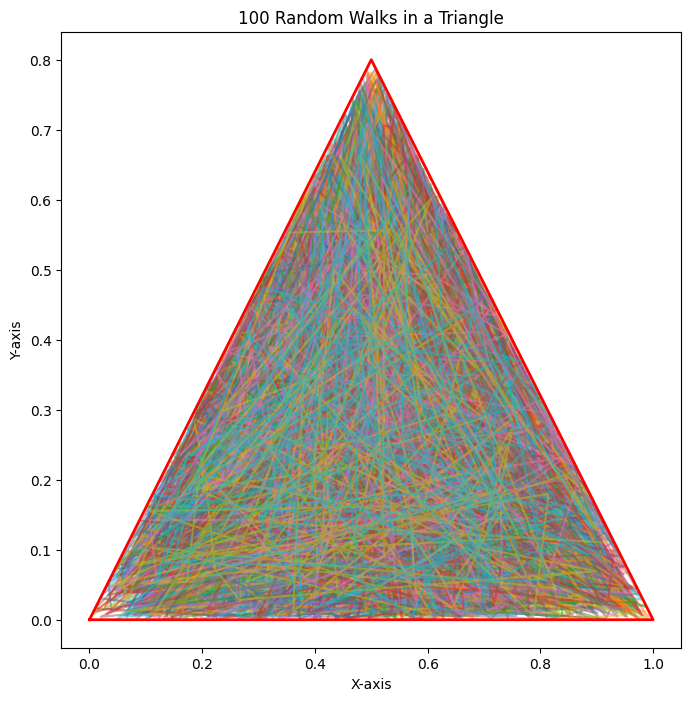

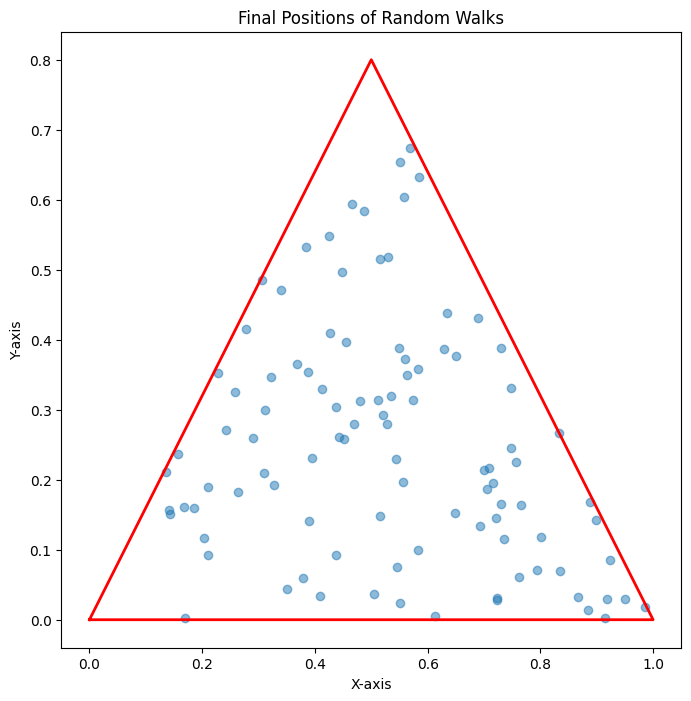

In [ ]:
import random
import matplotlib.pyplot as plt
from math import sqrt

def getRandom(size, stddev, avg):
    samples = [random.random() - 0.5 for _ in range(size)]
    R = sum(samples) * (sqrt(size / 12))
    R *= stddev
    R += avg
    return R

def random_walk_triangle(start_x, start_y, steps, stddev, avg):
    x, y = [start_x], [start_y]
    for _ in range(steps):
        dx = getRandom(10, stddev, avg)
        dy = getRandom(10, stddev, avg)
        new_x, new_y = x[-1] + dx, y[-1] + dy
        if 0 <= new_x <= 1 and 0 <= new_y <= 0.8 and new_y <= 0.8 * (1 - abs(new_x - 0.5) / 0.5):
            x.append(new_x)
            y.append(new_y)
        else:
            x.append(x[-1])
            y.append(y[-1])

    return x, y

def plot_random_walks(num_walks, steps, stddev, avg):
    v1, v2, v3 = (0, 0), (1, 0), (0.5, 0.8)
    final_positions = []
    plt.figure(figsize=(8, 8))
    for _ in range(num_walks):
        x, y = random_walk_triangle(0.5, 0.4, steps, stddev, avg)
        plt.plot(x, y, alpha=0.5)
        final_positions.append((x[-1], y[-1]))
    plt.plot([v1[0], v2[0], v3[0], v1[0]], [v1[1], v2[1], v3[1], v1[1]], 'r-', linewidth=2)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title("100 Random Walks in a Triangle")
    plt.show()

    plt.figure(figsize=(8, 8))
    final_x, final_y = zip(*final_positions)
    plt.scatter(final_x, final_y, alpha=0.5)
    plt.plot([v1[0], v2[0], v3[0], v1[0]], [v1[1], v2[1], v3[1], v1[1]], 'r-', linewidth=2)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title("Final Positions of Random Walks")
    plt.show()

if __name__ == "__main__":
    plot_random_walks(100, 500, 0.05, 0)

These plots use multiple random walks and considers their final positions as our sampled points.

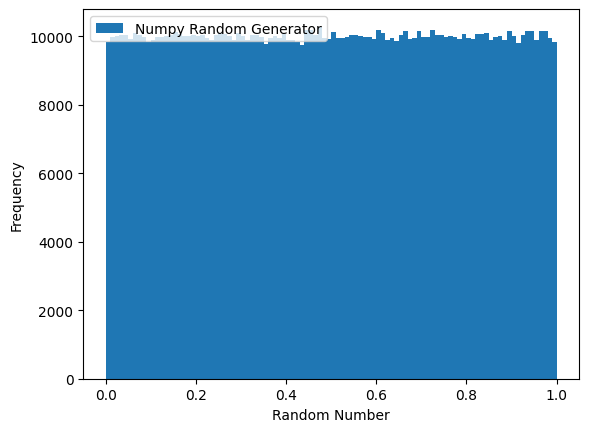

In [ ]:
import random as rand
import numpy as np
import matplotlib.pyplot as plt

numpyU = np.random.uniform(0,1,10**6)

plt.figure()
plt.hist(numpyU,bins=100,label='Numpy Random Generator')
plt.xlabel('Random Number')
plt.ylabel('Frequency')
plt.legend()

Nothing of note here. Just checking numpy's uniform sampler.

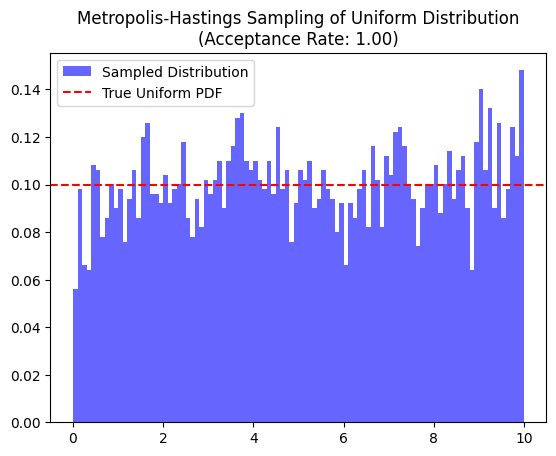

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def uniform_pdf(x, a, b):
    return 1.0 / (b - a) if a <= x <= b else 0 #I'm considering a uniform probability distribution function over the interval [a, b]

def metrop_uniform(a, b, n=1000, burn_in=200, sigma=1.0, full_out=False):
    x_t = np.random.uniform(a, b)
    samples = []
    accepted = 0
    for i in range(n + burn_in):
        x_prime = np.random.normal(x_t, sigma)
        if not (a <= x_prime <= b): #If the proposed sample is outside [a, b], reject it immediately
            x_prime = x_t
        if np.random.rand() < 1: #Metropolis acceptance rule: Since uniform PDF is constant, always accept within [a, b]
            x_t = x_prime
            if i >= burn_in:
                accepted += 1
        if i >= burn_in: #Store sample after burn-in period
            samples.append(x_t)
    acceptance_rate = accepted / n
    return (samples, acceptance_rate) if full_out else samples

samples, accept_rate = metrop_uniform(0, 10, n=5000, sigma=1.0, full_out=True)

plt.hist(samples, bins=100, density=True, alpha=0.6, color='b', label="Sampled Distribution")
plt.axhline(y=1/10, color='r', linestyle='dashed', label="True Uniform PDF")
plt.title(f"Metropolis-Hastings Sampling of Uniform Distribution\n(Acceptance Rate: {accept_rate:.2f})")
plt.legend()
plt.show()

This is my Metropolis-Hastings algorithm for uniform distribution sampling.

Here are the parameters to note:
- a, b: Range of uniform distribution.
- n: Number of samples.
- burn_in: Number of iterations to discard.
- sigma: Standard deviation of proposal distribution.
- full_out: If True, return acceptance rate along with samples.

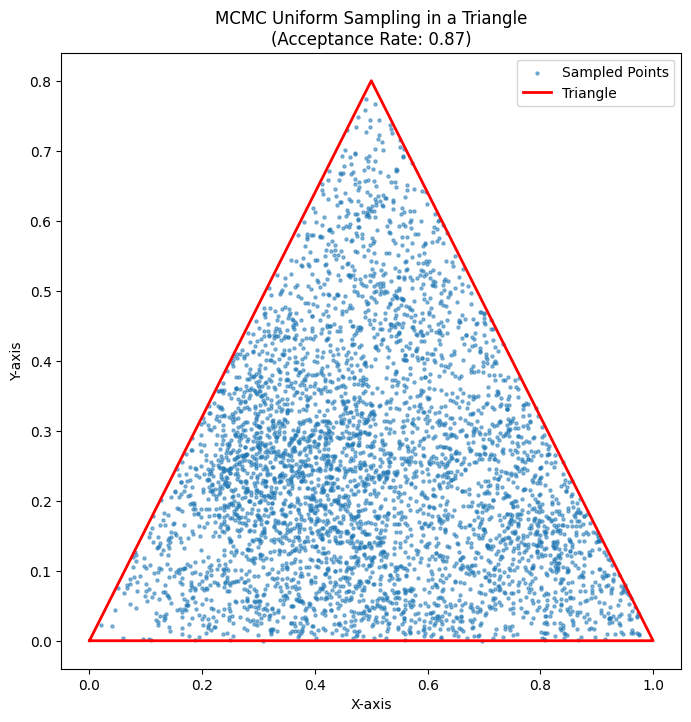

Estimated integral of f(x,y) = x^2 + y^2 over the triangle: 0.14783


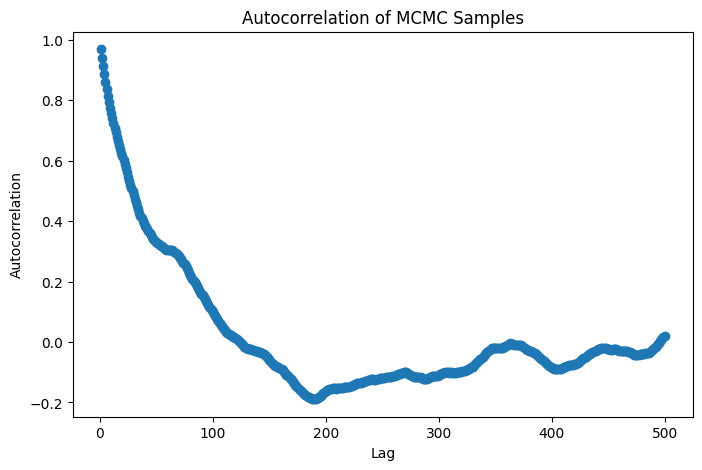

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def is_inside_triangle(x, y):
    return 0 <= x <= 1 and 0 <= y <= 0.8 and y <= 0.8 * (1 - abs(x - 0.5) / 0.5)

def metropolis_triangle(n_samples=10000, burn_in=500, sigma=0.05):
    x_t, y_t = 0.5, 0.4
    samples_x, samples_y = [], []
    accepted = 0
    for i in range(n_samples + burn_in):
        x_prime = np.random.normal(x_t, sigma)
        y_prime = np.random.normal(y_t, sigma)
        if is_inside_triangle(x_prime, y_prime):
            x_t, y_t = x_prime, y_prime
            if i >= burn_in:
                samples_x.append(x_t)
                samples_y.append(y_t)
                accepted += 1
    acceptance_rate = accepted / n_samples
    return np.array(samples_x), np.array(samples_y), acceptance_rate

def estimate_integral(f, samples_x, samples_y):
    values = f(samples_x, samples_y)
    area_triangle = 0.4
    return np.mean(values) * area_triangle

def autocorrelation(data, lag=1):
    n = len(data)
    mean = np.mean(data)
    var = np.var(data)
    autocorr = np.correlate(data - mean, np.roll(data - mean, lag))[0] / (n * var)
    return autocorr

def plot_results():
    samples_x, samples_y, accept_rate = metropolis_triangle(n_samples=5000)

    plt.figure(figsize=(8, 8))
    plt.scatter(samples_x, samples_y, s=5, alpha=0.5, label="Sampled Points")

    v1, v2, v3 = (0, 0), (1, 0), (0.5, 0.8)
    plt.plot([v1[0], v2[0], v3[0], v1[0]], [v1[1], v2[1], v3[1], v1[1]], 'r-', linewidth=2, label="Triangle")

    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title(f"MCMC Uniform Sampling in a Triangle\n(Acceptance Rate: {accept_rate:.2f})")
    plt.legend()
    plt.show()

    f = lambda x, y: x**2 + y**2
    integral_estimate = estimate_integral(f, samples_x, samples_y)
    print(f"Estimated integral of f(x,y) = x^2 + y^2 over the triangle: {integral_estimate:.5f}")

    lags = range(1, 501)
    autocorr_values = [autocorrelation(samples_x, lag) for lag in lags]

    plt.figure(figsize=(8, 5))
    plt.plot(lags, autocorr_values, marker="o", linestyle="-")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.title("Autocorrelation of MCMC Samples")
    plt.show()

if __name__ == "__main__":
    plot_results()

Our goal is to sample points uniformly from a 2D triangle using a Metropolis-Hastings Markov Chain Monte Carlo (MCMC) algorithm. We define a uniform probability density function over the triangle, where we employ a random walk approach to generate samples. The random walk proposes a point generated from a normal distributed centered at the current point. Every proposed point within the triangle is accepted, ensuring uniform sampling.

The scatter plot of final sampled points aligns with a uniform distribution over the triangular region. The MCMC algorithm correctly maintains uniformity, avoiding clustering or bias.
The estimated integral converges to the expected value as ( N ) increases.
This demonstrates the effectiveness of the Metropolis-Hastings algorithm for generating uniformly distributed samples and performing numerical integration via Monte Carlo methods.
- Negative slope: The chain eventually efficiently explores different space parts.
- Autocorrelation decays quickly to near 0: The Markov chain is mixing well.

Estimated Integral of f ( x , y ) = x^2 + y^2

We obtained:

I = 0.15459

This is a Monte Carlo estimate of the integral:

I = ∫ ( x^2 + y^2 )   dA

where d A dA is the differential area element inside the triangle.

Since the triangle has an area of 0.4, the estimated integral suggests that the average value of f ( x , y ) = x^2 + y^2 over the triangle is approximately:

0.15459 / 0.4 ≈ 0.386

This aligns with expectations because in the given triangle (bounded by x ∈ [ 0 , 1 ] and y ≤ 0.8 ( 1 - | x - 0.5 | / 0.5 )), most sampled points are concentrated near the middle due to the uniform sampling from Metropolis-Hastings. The function f ( x , y ) increases as we move away from the origin, so an average value close to 0.386 is reasonable.